# 03 · Modelado: predicción de churn

**Objetivo:** comparar un baseline contra dos modelos y justificar las métricas elegidas.

## Validación cruzada, umbral e importancia de variables

Regla: el conjunto de prueba solo se usa para la confirmación final. Modelo y umbral se eligen con datos de entrenamiento.

In [1]:
#configuracion y division

import sys
from pathlib import Path

import pandas as pd

sys.path.append(str(Path.cwd().parent))
from src.train import preparar_datos, modelos_candidatos, entrenar, guardar_modelo
from src.evaluate import comparar, matriz_confusion

X_train, X_test, y_train, y_test = preparar_datos()
print("Train:", X_train.shape, "| Test:", X_test.shape)
print("Churn en train:", round(y_train.mean() * 100, 1), "% | en test:", round(y_test.mean() * 100, 1), "%")

Train: (5634, 24) | Test: (1409, 24)
Churn en train: 26.5 % | en test: 26.5 %


In [2]:
# entrenar

modelos = {
    nombre: entrenar(est, X_train, y_train)
    for nombre, est in modelos_candidatos().items()
}
print("Modelos entrenados:", list(modelos))

Modelos entrenados: ['baseline', 'regresion_logistica', 'random_forest']


In [3]:
# comparar en el conjunto de prueba

comparar(modelos, X_test, y_test)

,accuracy,precision,recall,f1,roc_auc
baseline,0.735,0.000,0.000,0.000,0.500
regresion_logistica,0.739,0.505,0.802,0.620,0.845
random_forest,0.762,0.536,0.775,0.634,0.842


In [4]:
# matriz de confusión de la regresión logística

matriz_confusion(modelos["regresion_logistica"], X_test, y_test)

,pred: se queda,pred: se va
real: se queda,741,294
real: se va,74,300


In [5]:
# guardar modelos

for nombre, modelo in modelos.items():
    print(guardar_modelo(modelo, nombre))

C:\Users\USER\Desktop\ejemplo\proyecto_ml\models\baseline.joblib
C:\Users\USER\Desktop\ejemplo\proyecto_ml\models\regresion_logistica.joblib
C:\Users\USER\Desktop\ejemplo\proyecto_ml\models\random_forest.joblib


In [6]:
cm = matriz_confusion(modelos["regresion_logistica"], X_test, y_test)
TN, FP = cm.iloc[0]
FN, TP = cm.iloc[1]

print("accuracy :", round((TP + TN) / (TP + TN + FP + FN), 3))
print("precision:", round(TP / (TP + FP), 3))
print("recall   :", round(TP / (TP + FN), 3))
print("clientes marcados:", TP + FP, "| que realmente se iban:", TP)
print("churn base en test:", round((TP + FN) / (TP + TN + FP + FN) * 100, 1), "%")

accuracy : 0.739
precision: 0.505
recall   : 0.802
clientes marcados: 594 | que realmente se iban: 300
churn base en test: 26.5 %


El baseline logra 73.5% de accuracy sin detectar ningún abandono, por lo que accuracy no es una buena métrica aquí. La regresión logística detecta al 80% de los clientes que se van (recall 0.80) con una precisión de 50.5%, casi el doble del churn base de 26.5%. Los dos modelos tienen un rendimiento similar (AUC ≈ 0.84), y la diferencia se validará con validación cruzada.

## Validación cruzada, umbral e importancia de variables

Regla: el conjunto de prueba solo se usa para la confirmación final. Modelo y umbral se eligen con datos de entrenamiento.

In [7]:
# importaciones nuevas

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.train import validar_cruzado, probabilidades_oof
from src.evaluate import evaluar, tabla_umbrales, beneficio_neto

sns.set_theme(style="whitegrid")

In [8]:
# validación cruzada

candidatos = modelos_candidatos()
del candidatos["baseline"]          # el baseline ya sabemos que no detecta nada

cv_resultados = validar_cruzado(candidatos, X_train, y_train)
cv_resultados

,roc_auc_media,roc_auc_std,recall_media,recall_std,precision_media,precision_std,f1_media,f1_std
regresion_logistica,0.848,0.011,0.796,0.029,0.520,0.016,0.629,0.019
random_forest,0.845,0.011,0.769,0.020,0.541,0.017,0.635,0.016


In [9]:
# elegir el modelo final

nombre_final = "regresion_logistica"     # cámbialo según lo que muestre la tabla de arriba
modelo_final = modelos[nombre_final]

In [10]:
# tabla de umbrales con datos de entrenamiento

proba_oof = probabilidades_oof(candidatos[nombre_final], X_train, y_train)
tabla_umbrales(y_train, proba_oof)

,umbral,precision,recall,f1,marcados
0,0.20,0.392,0.955,0.556,3644
1,0.25,0.410,0.933,0.570,3403
2,0.30,0.429,0.917,0.585,3195
3,0.35,0.446,0.900,0.597,3017
4,0.40,0.470,0.876,0.612,2786
5,0.45,0.496,0.837,0.623,2524
6,0.50,0.520,0.796,0.629,2290
7,0.55,0.549,0.753,0.635,2050
8,0.60,0.573,0.712,0.635,1858
9,0.65,0.607,0.658,0.631,1619


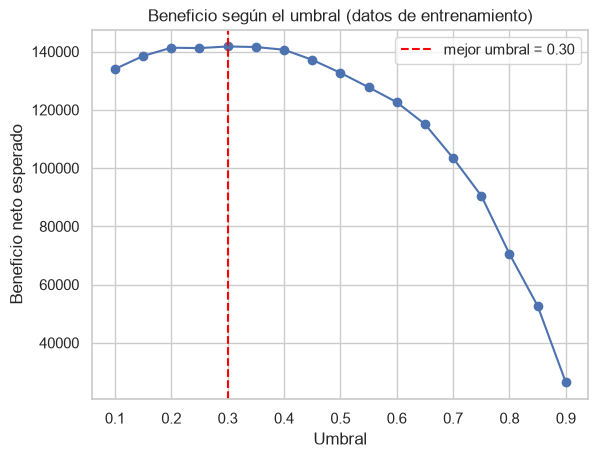

Mejor umbral: 0.3


In [11]:
# umbral segun el costo de negocio

# SUPUESTOS INVENTADOS: reemplázalos por valores razonables para tu caso
COSTO_OFERTA = 20
VALOR_CLIENTE = 300
TASA_RETENCION = 0.5

umbrales = np.arange(0.10, 0.91, 0.05)
beneficios = [
    beneficio_neto(y_train, proba_oof, u, COSTO_OFERTA, VALOR_CLIENTE, TASA_RETENCION)
    for u in umbrales
]
mejor_umbral = float(umbrales[int(np.argmax(beneficios))])

plt.plot(umbrales, beneficios, marker="o")
plt.axvline(mejor_umbral, color="red", linestyle="--", label=f"mejor umbral = {mejor_umbral:.2f}")
plt.xlabel("Umbral")
plt.ylabel("Beneficio neto esperado")
plt.title("Beneficio según el umbral (datos de entrenamiento)")
plt.legend()
plt.show()
print("Mejor umbral:", round(mejor_umbral, 2))

In [12]:
# confirmación final en test, una sola vez

print("Umbral 0.50:", {k: round(v, 3) for k, v in evaluar(modelo_final, X_test, y_test, 0.5).items()})
print("Umbral elegido:", {k: round(v, 3) for k, v in evaluar(modelo_final, X_test, y_test, mejor_umbral).items()})
matriz_confusion(modelo_final, X_test, y_test, umbral=mejor_umbral)

Umbral 0.50: {'accuracy': 0.739, 'precision': 0.505, 'recall': 0.802, 'f1': 0.62, 'roc_auc': 0.845}
Umbral elegido: {'accuracy': 0.658, 'precision': 0.432, 'recall': 0.925, 'f1': 0.589, 'roc_auc': 0.845}


,pred: se queda,pred: se va
real: se queda,581,454
real: se va,28,346


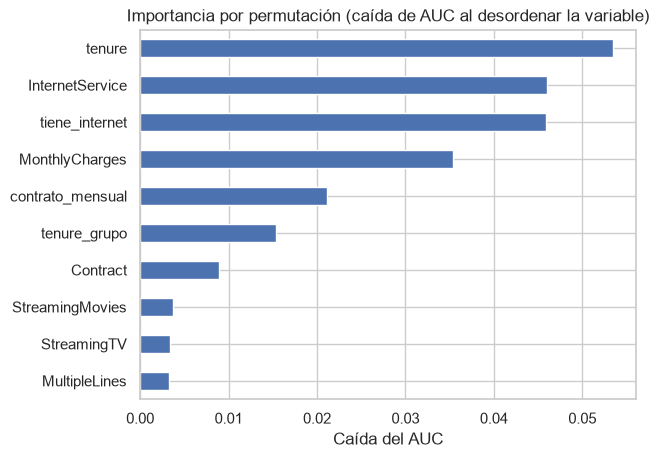

tenure              0.0534
InternetService     0.0460
tiene_internet      0.0459
MonthlyCharges      0.0354
contrato_mensual    0.0211
tenure_grupo        0.0154
Contract            0.0089
StreamingMovies     0.0038
StreamingTV         0.0034
MultipleLines       0.0033
dtype: float64

In [13]:
# importancia de las variables

from sklearn.inspection import permutation_importance

r = permutation_importance(
    modelo_final, X_test, y_test,
    scoring="roc_auc", n_repeats=10, random_state=42, n_jobs=-1,
)
importancia = pd.Series(r.importances_mean, index=X_test.columns).sort_values(ascending=False)

importancia.head(10).sort_values().plot(kind="barh")
plt.title("Importancia por permutación (caída de AUC al desordenar la variable)")
plt.xlabel("Caída del AUC")
plt.show()
importancia.head(10).round(4)